In [1]:
from sklearn.linear_model import LogisticRegression

from FeDa4Fair.dataset import FairFederatedDataset
from FeDa4Fair.utils.data_utils import generate_multiobjective_bias
from FeDa4Fair.visualization import plot_multi_attribute_fairness

# Create a dataset with conflicting values for the same sensitive attribute

In this notebook we'll create a Federated Dataset in which we have two groups of clients. All of them are unfair toward the same sensitive attribute but in opposite directions.

We'll use the Dutch Dataset from HF, the sensitive attribute will be the gender, one group of clients will be unfair against male and one unfair toward female. 

In [2]:
num_clients = 100
group_split = 50
client_names = [str(i) for i in range(num_clients)]

# Configure groups to show opposite bias directions for 'sex_binary'
# We use aggressive bias injection to ensure the model learns the bias.
group_configs = [
    {
        "group_id": "Group A (Favors 1)",
        "num_clients": group_split,
        "configs": [
            {
                "attribute": "sex_binary",
                "value": 0,  # Bias against 0 (favors 1)
                "drop_mean": 0.9,
                "drop_std": 0.05,
                "flip_mean": 0.3,
                "flip_std": 0.05,
            }
        ],
    },
    {
        "group_id": "Group B (Favors 0)",
        "num_clients": num_clients - group_split,
        "configs": [
            {
                "attribute": "sex_binary",
                "value": 1,  # Bias against 1 (favors 0)
                "drop_mean": 0.3,
                "drop_std": 0.05,
                "flip_mean": 0.1,
                "flip_std": 0.05,
            }
        ],
    },
]

modifications = generate_multiobjective_bias(num_clients, group_configs, client_names)

/Users/lucacorbucci/Documents/GitHub/FeDa4Fair/.venv/lib/python3.12/site-packages/flwr_datasets/utils.py:109: UserWarning: The currently tested dataset are ['mnist', 'ylecun/mnist', 'cifar10', 'uoft-cs/cifar10', 'fashion_mnist', 'zalando-datasets/fashion_mnist', 'sasha/dog-food', 'zh-plus/tiny-imagenet', 'scikit-learn/adult-census-income', 'cifar100', 'uoft-cs/cifar100', 'svhn', 'ufldl-stanford/svhn', 'sentiment140', 'stanfordnlp/sentiment140', 'speech_commands', 'LIUM/tedlium', 'flwrlabs/femnist', 'flwrlabs/ucf101', 'flwrlabs/ambient-acoustic-context', 'jlh/uci-mushrooms', 'Mike0307/MNIST-M', 'flwrlabs/usps', 'scikit-learn/iris', 'flwrlabs/pacs', 'flwrlabs/cinic10', 'flwrlabs/caltech101', 'flwrlabs/office-home', 'flwrlabs/fed-isic2019']. Given: lucacorbucci/Dutch_census_binary_marital_status.
  warnings.warn(


Preparing dataset...


/Users/lucacorbucci/Documents/GitHub/FeDa4Fair/.venv/lib/python3.12/site-packages/flwr_datasets/metrics/utils.py:130: UserWarning: The verbose names can not be established. The column specified by 'column_name' needs to be of type 'ClassLabel' to create a verbose names. The available names will used.
  warnings.warn(
/Users/lucacorbucci/Documents/GitHub/FeDa4Fair/src/FeDa4Fair/dataset/fair_dataset.py:213: UserWarning: Your current data contains columns with sensitive attributes. If these should not be in the training data later, please remove them before training.
  self._prepare_dataset()


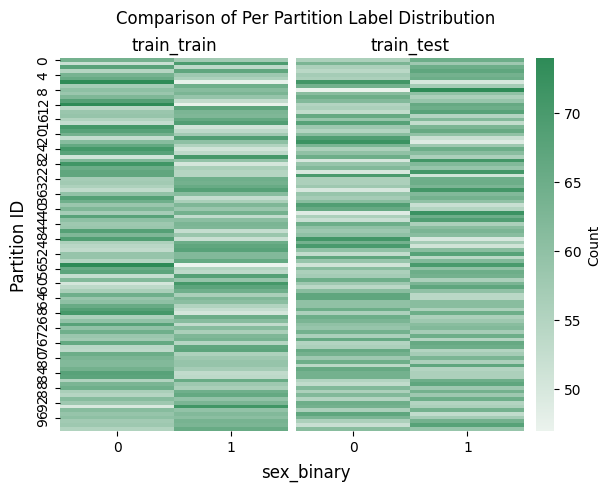

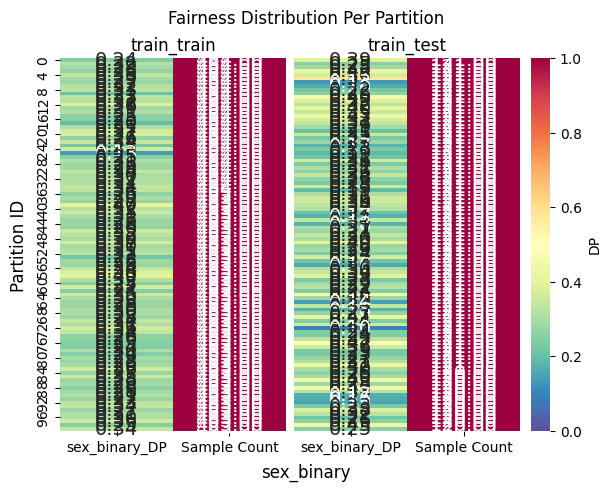

In [3]:
# Initialize Dataset with Cross-Silo setting (train/test split per client)
fds = FairFederatedDataset(
    dataset="lucacorbucci/Dutch_census_binary_marital_status",
    split="all",
    partitioners={"train": num_clients},
    label_name="occupation_binary",
    sensitive_attributes=["sex_binary"],
    modification_dict=modifications,
    fl_setting="cross-silo",
    perc_train_val_test=[0.8, 0.2],
    client_names=client_names,
)

print("Preparing dataset...")
fds.prepare()

In [4]:
print("\nVerifying training sample counts per client:")
for client_id in range(num_clients):
    partition = fds.load_partition(client_id, "train_train")
    df = partition.to_pandas()
    group_label = "Group A (Favors 1)" if client_id < 5 else "Group B (Favors 0)"
    counts = df["sex_binary"].value_counts().to_dict()
    print(f"Client {client_id:2} ({group_label}): 0 -> {counts.get(0, 0):4}, 1 -> {counts.get(1, 0):4}")


Verifying training sample counts per client:
Client  0 (Group A (Favors 1)): 0 ->  101, 1 ->  236
Client  1 (Group A (Favors 1)): 0 ->   88, 1 ->  258
Client  2 (Group A (Favors 1)): 0 ->  121, 1 ->  229
Client  3 (Group A (Favors 1)): 0 ->  110, 1 ->  253
Client  4 (Group A (Favors 1)): 0 ->  104, 1 ->  237
Client  5 (Group B (Favors 0)): 0 ->  101, 1 ->  233
Client  6 (Group B (Favors 0)): 0 ->   90, 1 ->  218
Client  7 (Group B (Favors 0)): 0 ->   94, 1 ->  249
Client  8 (Group B (Favors 0)): 0 ->   70, 1 ->  243
Client  9 (Group B (Favors 0)): 0 ->  121, 1 ->  246
Client 10 (Group B (Favors 0)): 0 ->  108, 1 ->  239
Client 11 (Group B (Favors 0)): 0 ->   73, 1 ->  228
Client 12 (Group B (Favors 0)): 0 ->  115, 1 ->  218
Client 13 (Group B (Favors 0)): 0 ->   84, 1 ->  254
Client 14 (Group B (Favors 0)): 0 ->  102, 1 ->  246
Client 15 (Group B (Favors 0)): 0 ->   91, 1 ->  245
Client 16 (Group B (Favors 0)): 0 ->   92, 1 ->  252
Client 17 (Group B (Favors 0)): 0 ->  108, 1 ->  257



Generating model-based fairness plot...


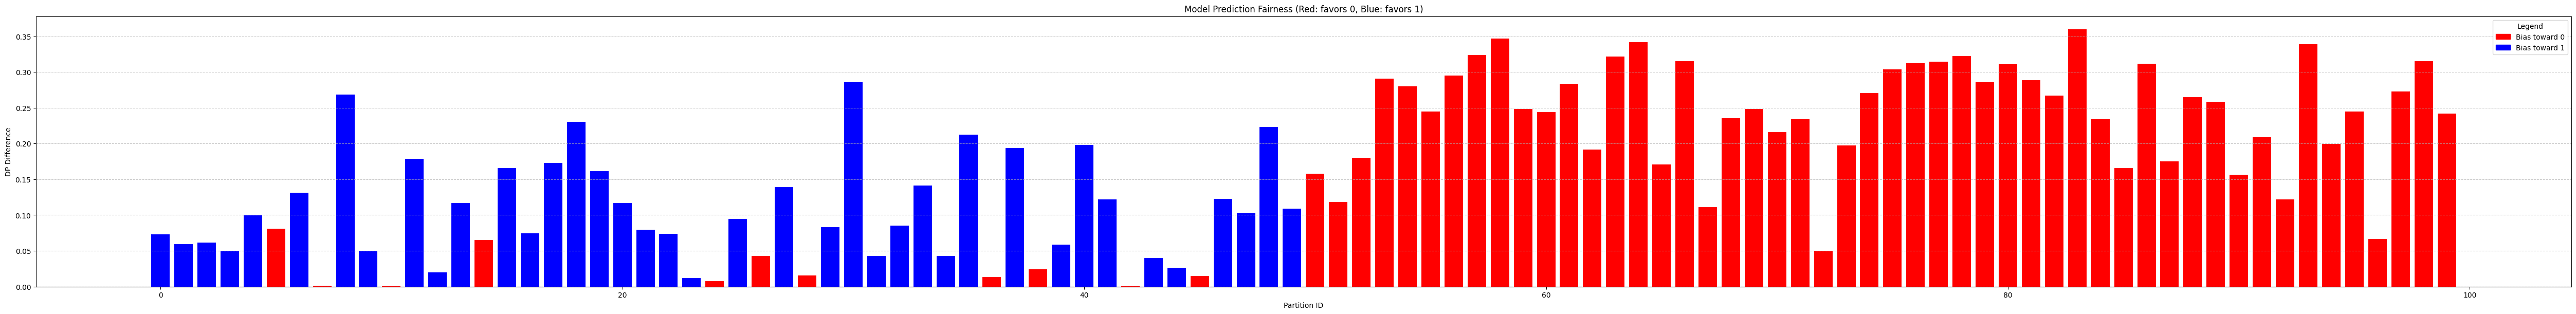

In [5]:
print("\nGenerating model-based fairness plot...")

# We define colors: 0 -> Red (Favors 0), 1 -> Blue (Favors 1)
val_colors = {0: "red", 1: "blue"}

# Pass the model to plot_multi_attribute_fairness
# It will automatically train on 'train_train' and evaluate on 'train_test'
fig, ax, df_results = plot_multi_attribute_fairness(
    partitioner=fds.partitioners["train_train"],
    partitioner_test=fds.partitioners["train_test"],
    label_name="occupation_binary",
    sens_atts=["sex_binary"],
    fairness_metric="DP",
    model=LogisticRegression(max_iter=1000, solver="liblinear"),
    size_unit="value",
    value_colors=val_colors,
    fds=fds,
    split="train_train",
    test_split="train_test",
    title="Model Prediction Fairness (Red: favors 0, Blue: favors 1)",
)

In [6]:
cols_to_print = ["Accuracy", "sex_binary_0_1", "sex_binary_1_0"]
print(df_results[cols_to_print])

              Accuracy  sex_binary_0_1  sex_binary_1_0
Partition ID                                          
0             0.761905       -0.072874        0.072874
1             0.746988       -0.059310        0.059310
2             0.769231       -0.061538        0.061538
3             0.790698       -0.050275        0.050275
4             0.755814       -0.099432        0.099432
...                ...             ...             ...
95            0.853448        0.244593       -0.244593
96            0.778761        0.066667       -0.066667
97            0.854545        0.272487       -0.272487
98            0.827586        0.314904       -0.314904
99            0.780702        0.241571       -0.241571

[100 rows x 3 columns]
